# Imports

In [1]:
import subprocess
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)

import sys
sys.path.append('..')
from pipeline import (
    RF_FEATURES, SVM_FEATURES, SVM_SCALE_COLS,
    RF_MINMAX_COLS, RF_STANDARD_COLS,
    filter_port, decode_attack_labels, ATTACK_LABELS,
)

# Label dataset -IGNORE IT-

In [ ]:
#! No longer needed, I am saving each attack type in a separate file 

# label_dataset.py will stamp Attack_type onto traffic_log.csv using
# the timestamps written by run_attack.py.
# Output: traffic_log_labeled.csv
result = subprocess.run(
    ['python', 'label_dataset.py'],
    cwd='../services/attacks/',
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Labeling dataset using attack windows from ../../ryu-controller/run_attack_log.json...
Loaded 7 attack windows from ../../ryu-controller/run_attack_log.json
  SLOWLORIS        start=1776354656.03  end=1776355056.13  duration=400s
  UDP_flood        start=1776355106.14  end=1776355246.25  duration=140s
  ICMP_flood       start=1776358365.35  end=1776358505.45  duration=140s
  SYN_flood        start=1776358555.50  end=1776358695.61  duration=140s
  UDP_flood        start=1776358745.66  end=1776358885.77  duration=140s
  HTTP_flood       start=1776358935.82  end=1776359075.93  duration=140s
  LAND_attack      start=1776359125.99  end=1776359266.10  duration=140s

Processing ../../ryu-controller/traffic_log.csv line-by-line to avoid memory limits...

Labeling results:
  Total rows  : 4107420
  Attack rows : 1527143
  Normal rows : 2580277

Attack type distribution:
SYN_flood       396480
UDP_flood       380310
ICMP_flood      354143
HTTP_flood      323400
LAND_attack     71100
SLOWLORIS   

# Load and Inspect

In [ ]:
import os
# import pandas as pd

# chunks = []
# for chunk in pd.read_csv('../ryu-controller/traffic_log_labeled.csv', chunksize=100000):
#     # keep attack traffic only and drop 'Normal' to save memory immediately
#     attack_chunk = chunk[chunk['Traffic'] == 'Attack']
#     chunks.append(attack_chunk)

# df = pd.concat(chunks, ignore_index=True)

# print(df['Attack_type'].value_counts())
# print(f'Total attack samples: {len(df)}')

# CSV_DIR = '../ryu-controller/'


# # attack traffic - one file per attack type
# attack_names = ['ICMP_flood', 'SYN_flood', 'UDP_flood',
#                 'HTTP_flood', 'LAND_attack', 'SLOWLORIS']

# frames = []
# for name in attack_names:
#     path = os.path.join(CSV_DIR, f'traffic_{name}.csv')
#     if os.path.exists(path):
#         df_atk = pd.read_csv(path)
#         print(f'{name}: {len(df_atk):,} rows')
#         frames.append(df_atk)
#     else:
#         print(f'MISSING: {path} -- skipping')

# df_all = pd.concat(frames, ignore_index=True)

# print(f'\nTotal rows     : {len(df_all):,}')
# print(f'Attack rows    : {len(df_all[df_all["Traffic"] == "Attack"]):,}')
# print('\nAttack breakdown:')
# print(df_all[df_all['Traffic'] == 'Attack']['Attack_type'].value_counts())

# # for classifier training, keep attack rows only
# df = df_all[df_all['Traffic'] == 'Attack'].copy()

ICMP_flood: 365,757 rows


C:\Users\moulo\AppData\Local\Temp\ipykernel_16952\2163043953.py:26: DtypeWarning: Columns (0: Type_protocole) have mixed types. Specify dtype option on import or set low_memory=False.
  df_atk = pd.read_csv(path)


SYN_flood: 382,459 rows
UDP_flood: 347,059 rows
HTTP_flood: 251,600 rows
LAND_attack: 394,159 rows
SLOWLORIS: 1,538 rows

Total rows     : 1,742,572
Attack rows    : 1,742,572

Attack breakdown:
Attack_type
LAND_attack    394159
SYN_flood      382459
ICMP_flood     365757
UDP_flood      347059
HTTP_flood     251600
SLOWLORIS        1538
Name: count, dtype: int64


In [2]:
import os
import pandas as pd

CSV_DIR = '../ryu-controller/'

attack_names = ['ICMP_flood', 'SYN_flood', 'UDP_flood',
                'HTTP_flood', 'LAND_attack', 'SLOWLORIS']

frames = []
for name in attack_names:
    path = os.path.join(CSV_DIR, f'traffic_{name}.csv')
    if os.path.exists(path):
        # Read the raw file
        df_atk = pd.read_csv(path)
        initial_len = len(df_atk)
        
        # 1. Keep only Attack traffic
        df_atk = df_atk[df_atk['Traffic'] == 'Attack'].copy()
        
        # 2. Filter out cross-protocol contamination (due to flow entry life time in vSwitch) and enforce behavioral signatures
        if name == 'ICMP_flood':
            df_atk = df_atk[(df_atk['Ip_protocole'] == 'icmp') & (df_atk['Icmp'] != 0)]
            
        elif name == 'SYN_flood':
            df_atk = df_atk[(df_atk['Ip_protocole'] == 'tcp') & (df_atk['SYN'] != 0)]
            
        elif name == 'UDP_flood':
            df_atk = df_atk[(df_atk['Ip_protocole'] == 'udp') & (df_atk['Udp'] != 0)]
            
        elif name == 'HTTP_flood' or name == 'SLOWLORIS':
            # Both rely on TCP
            df_atk = df_atk[df_atk['Ip_protocole'] == 'tcp']
            
        elif name == 'LAND_attack':
            df_atk = df_atk[df_atk['Ip_protocole'] == 'tcp']
            # Synthetic fix: trust the attack label and force Same_ip=1 for LAND rows, even though it shoul already be like this
            df_atk['Same_ip'] = 1

        final_len = len(df_atk)
        print(f'{name}: Kept {final_len:,} pure attack rows (dropped {initial_len - final_len:,} normal/contaminated rows)')
        
        frames.append(df_atk)
    else:
        print(f'MISSING: {path} - skipping')

# Combine all cleaned subsets into one final DataFrame
df = pd.concat(frames, ignore_index=True)

print(f'\nTotal pure attack rows: {len(df):,}')
print('\nCurated Attack Breakdown:')
print(df['Attack_type'].value_counts())

C:\Users\moulo\AppData\Local\Temp\ipykernel_16496\20210857.py:14: DtypeWarning: Columns (0: Type_protocole) have mixed types. Specify dtype option on import or set low_memory=False.
  df_atk = pd.read_csv(path)


ICMP_flood: Kept 184,480 pure attack rows (dropped 20 normal/contaminated rows)
SYN_flood: Kept 252,300 pure attack rows (dropped 0 normal/contaminated rows)


C:\Users\moulo\AppData\Local\Temp\ipykernel_16496\20210857.py:14: DtypeWarning: Columns (0: Type_protocole) have mixed types. Specify dtype option on import or set low_memory=False.
  df_atk = pd.read_csv(path)


UDP_flood: Kept 10,410 pure attack rows (dropped 260,609 normal/contaminated rows)


C:\Users\moulo\AppData\Local\Temp\ipykernel_16496\20210857.py:14: DtypeWarning: Columns (0: Type_protocole) have mixed types. Specify dtype option on import or set low_memory=False.
  df_atk = pd.read_csv(path)


HTTP_flood: Kept 67,360 pure attack rows (dropped 205,140 normal/contaminated rows)
LAND_attack: Kept 217,801 pure attack rows (dropped 0 normal/contaminated rows)
SLOWLORIS: Kept 641 pure attack rows (dropped 0 normal/contaminated rows)

Total pure attack rows: 732,992

Curated Attack Breakdown:
Attack_type
SYN_flood      252300
LAND_attack    217801
ICMP_flood     184480
HTTP_flood      67360
UDP_flood       10410
SLOWLORIS         641
Name: count, dtype: int64


# Feature engineering

In [3]:
# Flow_duration / Packet_count = average time per packet
# Short = flood (many packets, short duration), Long = slowloris/HTTP (few packets, long duration)
df['Duration_per_packet'] = (
    df['Flow_duration'] / (df['Packet_count'] + 1e-6)
)

# Bytes_per_sec / Pkt_per_sec = average packet size
# SYN flood: tiny SYN packets (~60 bytes)
# HTTP flood: full HTTP GET requests (~500+ bytes)
# LAND attack: SYN packets like SYN flood but Same_ip=1
df['Avg_pkt_size'] = (
    df['Bytes_per_sec'] / (df['Pkt_per_sec'] + 1e-6)
).replace([np.inf, -np.inf], 0)

# Handle NA

In [4]:
df_orig = df.copy()

TCP_FLAG_COLS = ['SYN', 'ACK', 'FIN', 'PSH', 'RST']
for col in TCP_FLAG_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(-1)

FLAG_COLS = ['Tcp', 'Ftp', 'Icmp', 'Dns', 'Udp', 'Http', 'Smtp', 'Port_dst']
for col in FLAG_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0)

for col in ['Icmp_code', 'Icmp_type']:
    if col in df.columns:
        df[col] = df[col].fillna(-1)

# report
print("NaN values filled per column:")
for col in TCP_FLAG_COLS + FLAG_COLS + ['Icmp_code', 'Icmp_type']:
    if col in df.columns:
        n_filled = df_orig[col].isna().sum()
        print(f"  {col}: {n_filled} NaN filled")

del df_orig  # free memory

NaN values filled per column:
  SYN: 0 NaN filled
  ACK: 0 NaN filled
  FIN: 0 NaN filled
  PSH: 0 NaN filled
  RST: 0 NaN filled
  Tcp: 0 NaN filled
  Ftp: 0 NaN filled
  Icmp: 0 NaN filled
  Dns: 0 NaN filled
  Udp: 0 NaN filled
  Http: 0 NaN filled
  Smtp: 0 NaN filled
  Port_dst: 0 NaN filled
  Icmp_code: 0 NaN filled
  Icmp_type: 0 NaN filled


# Correlation

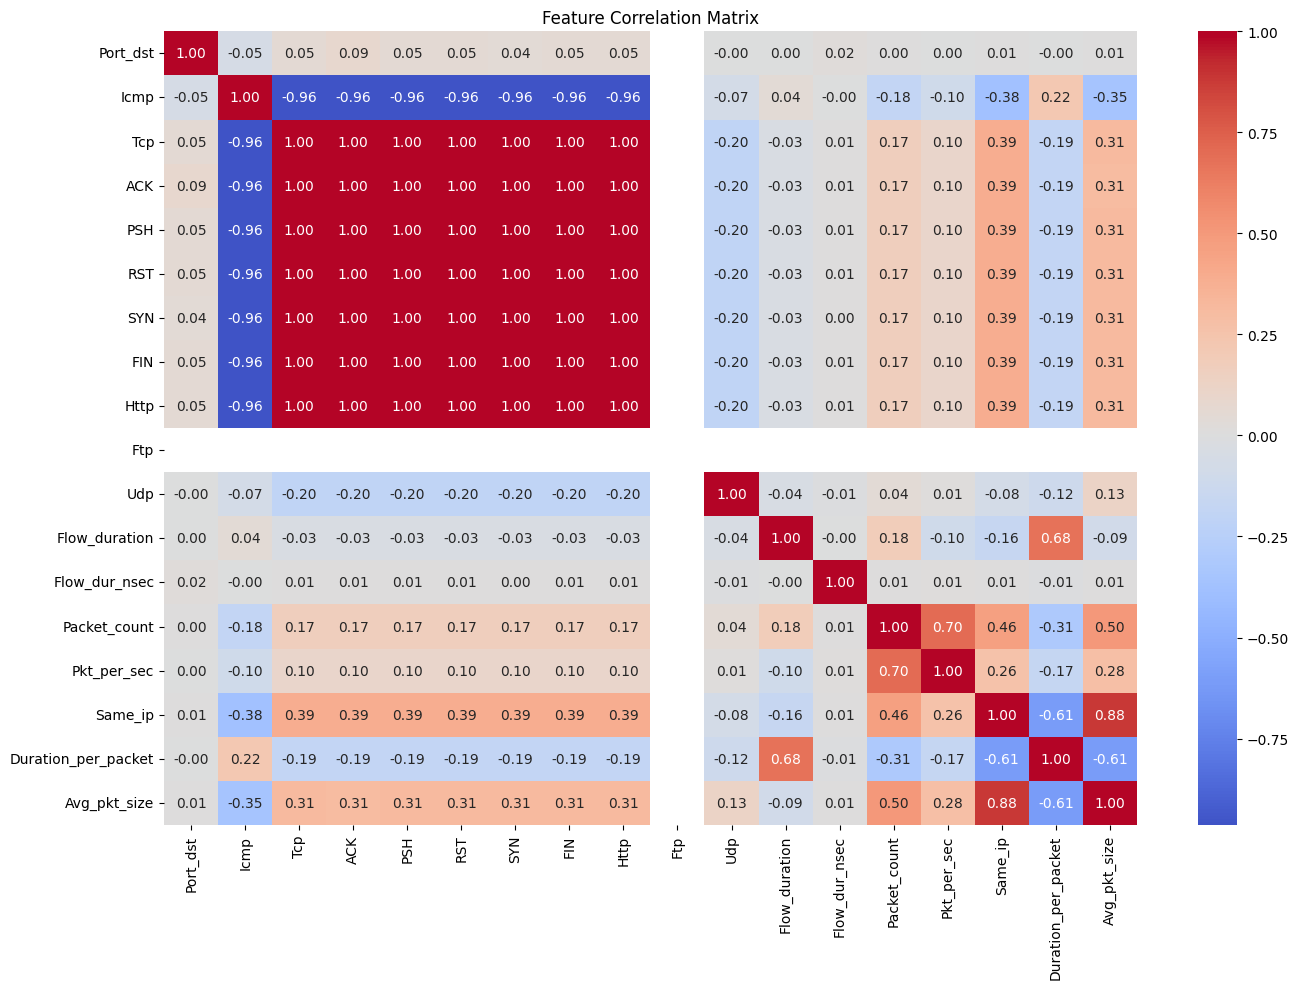

Highly correlated pairs (>0.9):
  Icmp <-> Tcp: -0.964
  Icmp <-> ACK: -0.963
  Icmp <-> PSH: -0.963
  Icmp <-> RST: -0.964
  Icmp <-> SYN: -0.963
  Icmp <-> FIN: -0.964
  Icmp <-> Http: -0.964
  Tcp <-> ACK: 0.999
  Tcp <-> PSH: 1.000
  Tcp <-> RST: 1.000
  Tcp <-> SYN: 1.000
  Tcp <-> FIN: 1.000
  Tcp <-> Http: 1.000
  ACK <-> PSH: 0.999
  ACK <-> RST: 0.999
  ACK <-> SYN: 0.998
  ACK <-> FIN: 0.999
  ACK <-> Http: 0.999
  PSH <-> RST: 1.000
  PSH <-> SYN: 0.999
  PSH <-> FIN: 1.000
  PSH <-> Http: 1.000
  RST <-> SYN: 1.000
  RST <-> FIN: 1.000
  RST <-> Http: 1.000
  SYN <-> FIN: 1.000
  SYN <-> Http: 1.000
  FIN <-> Http: 1.000


In [5]:
numeric_cols = RF_FEATURES + ['Duration_per_packet', 'Avg_pkt_size']

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# highly correlated pairs (threshold 0.9)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print('Highly correlated pairs (>0.9):')
for a, b, v in high_corr:
    print(f'  {a} <-> {b}: {v:.3f}')

# Drop redundant features based on correlation

In [8]:
import sys
sys.path.append('..')
from pipeline import RF_FEATURES

COLS_TO_DROP = [
    'Tcp',           # constant=1 for all TCP attacks after protocol filter
    'ACK',           # perfectly correlated with Tcp
    'PSH',           # perfectly correlated with Tcp
    'RST',           # perfectly correlated with Tcp
    'FIN',           # perfectly correlated with Tcp
    'Http',          # perfectly correlated with Tcp
    'Flow_duration',
]

FINAL_FEATURES = [f for f in RF_FEATURES if f not in COLS_TO_DROP]
print('Final features:', FINAL_FEATURES)

FINAL_FEATURES = FINAL_FEATURES + ['Duration_per_packet', 'Avg_pkt_size']
print('Added engineered features. Total:', len(FINAL_FEATURES))

Final features: ['Port_dst', 'Icmp', 'SYN', 'Ftp', 'Udp', 'Flow_dur_nsec', 'Packet_count', 'Pkt_per_sec', 'Same_ip']
Added engineered features. Total: 11


# Label encoding and train-test split

Label distribution:
label
4    252300
2    217801
1    184480
3     67360
5     10410
0       641
Name: count, dtype: int64


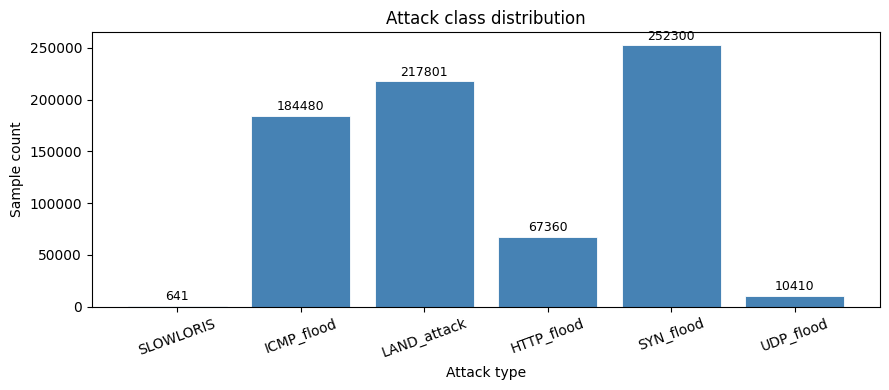

In [9]:
# encode attack types to integers matching ATTACK_LABELS
label_map = {v: k for k, v in ATTACK_LABELS.items()}

df['label'] = df['Attack_type'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

X = df[FINAL_FEATURES].copy()
X['Port_dst'] = X['Port_dst'].apply(filter_port)
y = df['label']

print('Label distribution:')
print(y.value_counts())

# class distribution bar chart
fig, ax = plt.subplots(figsize=(9, 4))
counts = y.value_counts().sort_index()
bars = ax.bar(
    [ATTACK_LABELS[i] for i in counts.index],
    counts.values,
    color='steelblue', edgecolor='white', linewidth=0.6,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9,
    )
ax.set_title('Attack class distribution')
ax.set_xlabel('Attack type')
ax.set_ylabel('Sample count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [30]:
print(sorted(y.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


# RF Preprocess

In [13]:
X_rf = X.copy()

mm  = MinMaxScaler()
std = StandardScaler()

# only scale cols that are still present after dropping
mm_cols  = [c for c in RF_MINMAX_COLS  if c in X_rf.columns]
std_cols = [c for c in RF_STANDARD_COLS if c in X_rf.columns]

X_rf[mm_cols]  = mm.fit_transform(X_rf[mm_cols])
X_rf[std_cols] = std.fit_transform(X_rf[std_cols])

# Save original y_train for the second SMOTE to avoid shape mismatch
X_train_rf, X_test_rf, y_train_orig, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
y_test.value_counts()
X_train_rf.shape, y_train_orig.shape, X_test_rf.shape, y_test.shape

((1211040, 11), (586393,), (146599, 11), (146599,))

# SVM Preprocess

In [14]:
X_svm = X.copy()

svm_std  = StandardScaler()
svm_cols = [c for c in SVM_SCALE_COLS if c in X_svm.columns]
X_svm[svm_cols] = svm_std.fit_transform(X_svm[svm_cols])

X_train_svm, X_test_svm, y_train_orig_svm, _ = train_test_split(
    X_svm, y, test_size=0.2, random_state=42, stratify=y
)

# Balancing the data with SMOTE

In [15]:
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(y_train_orig.value_counts().sort_index())

Class distribution before SMOTE:
label
0       513
1    147584
2    174240
3     53888
4    201840
5      8328
Name: count, dtype: int64


In [16]:
# Full SMOTE. I saw this on the instructor's notebook and it seems to work better, so I am trying it
smote = SMOTE(random_state=42)
X_train_rf_bal, y_train_rf_bal = smote.fit_resample(X_train_rf, y_train_orig)

X_train_rf = X_train_rf_bal
y_train     = y_train_rf_bal

print("\nRF Class distribution after SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())


RF Class distribution after SMOTE:
label
0    201840
1    201840
2    201840
3    201840
4    201840
5    201840
Name: count, dtype: int64


In [31]:
sorted(y_train.unique())

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

In [17]:
# same, full SMOTE on SVM-scaled data
smote_svm = SMOTE(random_state=42)
X_train_svm_bal, y_train_svm_bal = smote_svm.fit_resample(X_train_svm, y_train_orig_svm)

print("\nSVM Class distribution after SMOTE:")
print(pd.Series(y_train_svm_bal).value_counts().sort_index())


SVM Class distribution after SMOTE:
label
0    201840
1    201840
2    201840
3    201840
4    201840
5    201840
Name: count, dtype: int64


### This one is for SVC instead of LinearSVC

In [18]:
# 50k stratified subsample for SVC rbf
_, X_train_small, _, y_train_small = train_test_split(
    X_train_svm_bal,
    y_train_svm_bal,
    test_size=50000,
    stratify=y_train_svm_bal,
    random_state=42,
)
print(f"\nReduced SVM dataset: {len(X_train_small)} samples")
print(pd.Series(y_train_small).value_counts().sort_index())


Reduced SVM dataset: 50000 samples
label
0    8333
1    8333
2    8333
3    8334
4    8334
5    8333
Name: count, dtype: int64


# Train RF

In [21]:
# rf = RandomForestClassifier(n_estimators=130, random_state=42, n_jobs=-1) # it was 100 trees before
rf = RandomForestClassifier(
    n_estimators=110,        # optimal from OOB sweep = 130 trees
    max_depth=None,          # let trees grow fully
    min_samples_split=5,     # default 2, increase slightly to reduce overfitting
    min_samples_leaf=2,      # same reasoning
    max_features='sqrt',     # default
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

print('=' * 10)
print('Random Forest')
print('=' * 10)
print(classification_report(y_test, y_pred_rf,
      target_names=list(ATTACK_LABELS.values())))

Random Forest
              precision    recall  f1-score   support

   SLOWLORIS       0.95      0.95      0.95       128
  ICMP_flood       1.00      1.00      1.00     36896
 LAND_attack       1.00      1.00      1.00     43561
  HTTP_flood       0.75      0.94      0.83     13472
   SYN_flood       0.98      0.92      0.95     50460
   UDP_flood       1.00      1.00      1.00      2082

    accuracy                           0.97    146599
   macro avg       0.95      0.97      0.96    146599
weighted avg       0.97      0.97      0.97    146599



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


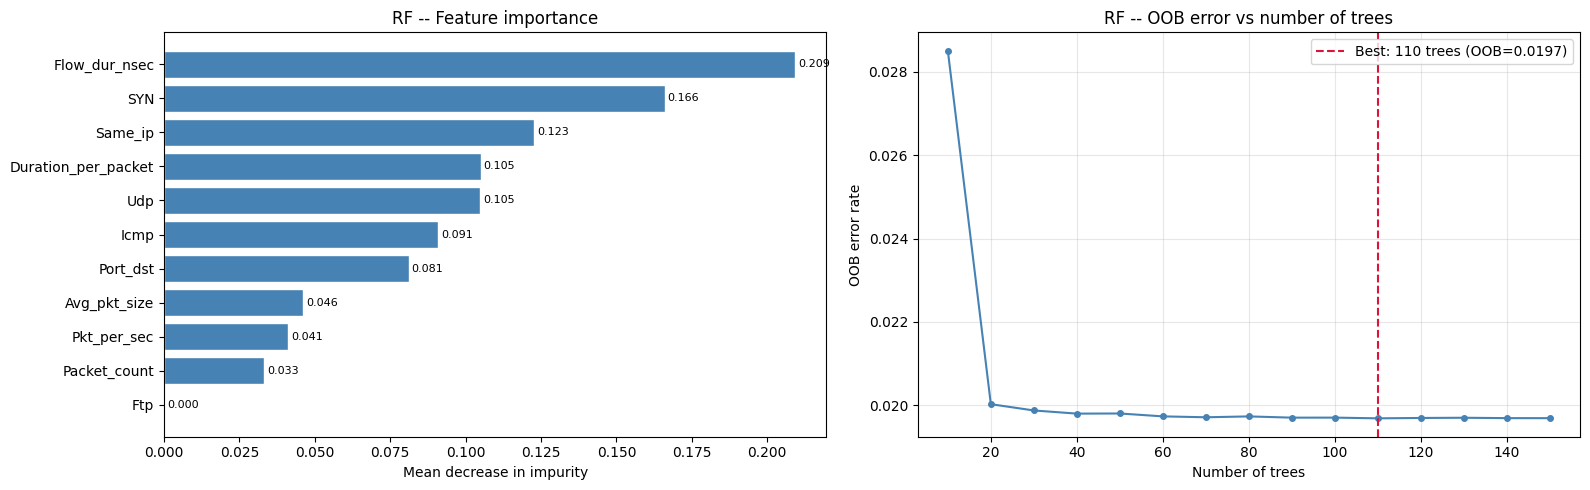

Optimal n_estimators from OOB sweep: 110


In [20]:
# RF: feature importance + OOB error curve

# --- feature importance ---
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = [FINAL_FEATURES[i] for i in indices]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(feat_names[::-1], importances[indices][::-1],
             color='steelblue', edgecolor='white')
axes[0].set_title('RF -- Feature importance')
axes[0].set_xlabel('Mean decrease in impurity')
for i, v in enumerate(importances[indices][::-1]):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# --- OOB error as a proxy for training convergence (n_estimators sweep) ---
# Trains RF with increasing n_estimators and records OOB error at each step.
# This is the RF equivalent of a loss curve.
rf_oob = RandomForestClassifier(
    warm_start=True, oob_score=True, random_state=42, n_jobs=-1
)
oob_errors = []
estimator_range = range(10, 151, 10)
for n in estimator_range:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train_rf, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

axes[1].plot(list(estimator_range), oob_errors,
             marker='o', markersize=4, color='steelblue', linewidth=1.5)
axes[1].set_title('RF -- OOB error vs number of trees')
axes[1].set_xlabel('Number of trees')
axes[1].set_ylabel('OOB error rate')
axes[1].grid(True, alpha=0.3)

best_n = list(estimator_range)[int(np.argmin(oob_errors))]
axes[1].axvline(best_n, color='crimson', linestyle='--',
                label=f'Best: {best_n} trees (OOB={min(oob_errors):.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Optimal n_estimators from OOB sweep: {best_n}')

In [22]:
imp = pd.Series(rf.feature_importances_, index=FINAL_FEATURES).sort_values(ascending=False)
print(imp)

Flow_dur_nsec          0.210388
SYN                    0.168317
Same_ip                0.125083
Duration_per_packet    0.105504
Udp                    0.095591
Icmp                   0.091486
Port_dst               0.083503
Avg_pkt_size           0.045811
Pkt_per_sec            0.041147
Packet_count           0.033169
Ftp                    0.000000
dtype: float64


# Train SVM

In [39]:
# LinearSVC: trains in O(n) time, proper multiclass, no kernel approximation.
# class_weight='balanced' handles the remaining imbalance after SMOTE.
# CalibratedClassifierCV wraps it to add predict_proba if needed later.

svm_linear = LinearSVC(C=10.0, max_iter=3000, dual='auto', random_state=42)
svm_linear.fit(X_train_svm_bal, y_train_svm_bal)
y_pred_linsvm = svm_linear.predict(X_test_svm)

print('=' * 10)
print('SVM (LinearSVC)')
print('=' * 10)
print(classification_report(y_test, y_pred_linsvm,
      target_names=list(ATTACK_LABELS.values())))

SVM (LinearSVC)
              precision    recall  f1-score   support

   SLOWLORIS       0.00      0.00      0.00       128
  ICMP_flood       0.00      0.00      0.00     36896
 LAND_attack       0.77      0.06      0.11     43561
  HTTP_flood       0.09      0.99      0.17     13472
   SYN_flood       0.00      0.00      0.00     50460
   UDP_flood       0.09      0.06      0.07      2082

    accuracy                           0.11    146599
   macro avg       0.16      0.18      0.06    146599
weighted avg       0.24      0.11      0.05    146599



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

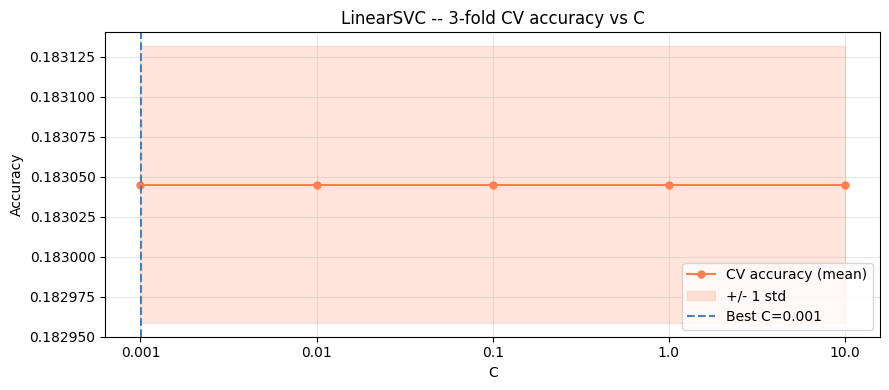

Best C: 0.001  (CV accuracy: 0.1830)


In [24]:
# LinearSVC C-sweep: same concept as before but actually runs fast now.
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
cv_means = []
cv_stds  = []

for C in C_values:
    clf = LinearSVC(C=C, max_iter=2000, class_weight='balanced',
                    random_state=42, dual='auto')
    # Using the balanced data. Removed n_jobs=-1 to prevent PicklingError
    # on massive datasets in Windows environments.
    scores = cross_val_score(clf, X_train_svm_bal, y_train_svm_bal,
                             cv=3, scoring='accuracy', n_jobs=1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([str(c) for c in C_values], cv_means,
        marker='o', color='coral', linewidth=1.5, markersize=5,
        label='CV accuracy (mean)')
ax.fill_between(range(len(C_values)),
                cv_means - cv_stds,
                cv_means + cv_stds,
                alpha=0.2, color='coral', label='+/- 1 std')
ax.set_title('LinearSVC -- 3-fold CV accuracy vs C')
ax.set_xlabel('C')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()

best_C = C_values[int(np.argmax(cv_means))]
ax.axvline(best_C, color='steelblue', linestyle='--',
           label=f'Best C={best_C}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best C: {best_C}  (CV accuracy: {max(cv_means):.4f})')

### Train SVC on smaller subset, due to big complexity of RBF kernal

In [25]:
svm_rbf = SVC(kernel='rbf', C=1000.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_small, y_train_small)

y_pred_svm = svm_rbf.predict(X_test_svm)

print('=' * 10)
print('SVM (RBF Kernel on 50k samples)')
print('=' * 10)
print(classification_report(y_test, y_pred_svm,
      target_names=list(ATTACK_LABELS.values())))

SVM (RBF Kernel on 50k samples)
              precision    recall  f1-score   support

   SLOWLORIS       0.00      0.09      0.00       128
  ICMP_flood       0.35      0.32      0.33     36896
 LAND_attack       0.00      0.00      0.00     43561
  HTTP_flood       0.27      0.14      0.18     13472
   SYN_flood       0.50      0.50      0.50     50460
   UDP_flood       0.05      1.00      0.09      2082

    accuracy                           0.28    146599
   macro avg       0.19      0.34      0.18    146599
weighted avg       0.29      0.28      0.27    146599



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

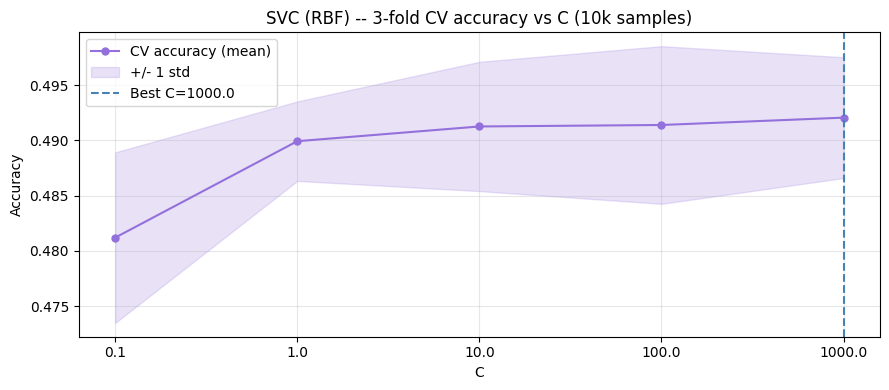

Best C for RBF: 1000.0  (CV accuracy: 0.4921)


In [ ]:
# SVC (RBF kernel) C-sweep on the reduced 10k dataset
C_values_rbf = [0.1, 1.0, 10.0, 100.0, 1000.0]
cv_means_rbf = []
cv_stds_rbf  = []

for C in C_values_rbf:
    clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    
    # Using the 10k subset so this finishes in a reasonable time.
    # n_jobs=1 is kept to avoid PicklingError on Windows.
    scores = cross_val_score(clf, X_train_small, y_train_small,
                             cv=3, scoring='accuracy', n_jobs=1)
    cv_means_rbf.append(scores.mean())
    cv_stds_rbf.append(scores.std())

cv_means_rbf = np.array(cv_means_rbf)
cv_stds_rbf  = np.array(cv_stds_rbf)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([str(c) for c in C_values_rbf], cv_means_rbf,
        marker='o', color='mediumpurple', linewidth=1.5, markersize=5,
        label='CV accuracy (mean)')
ax.fill_between(range(len(C_values_rbf)),
                cv_means_rbf - cv_stds_rbf,
                cv_means_rbf + cv_stds_rbf,
                alpha=0.2, color='mediumpurple', label='+/- 1 std')
ax.set_title('SVC (RBF) - 3-fold CV accuracy vs C (10k samples)')
ax.set_xlabel('C')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)

best_C_rbf = C_values_rbf[int(np.argmax(cv_means_rbf))]
ax.axvline(str(best_C_rbf), color='steelblue', linestyle='--',
           label=f'Best C={best_C_rbf}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best C for RBF: {best_C_rbf}  (CV accuracy: {max(cv_means_rbf):.4f})')

# Train XGBoost

In [56]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=10,          # was 6, your data needs deeper trees
    learning_rate=0.05,    # was 0.1, slower learning = better generalization
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,    # like min_samples_leaf in RF
    gamma=0.1,             # minimum loss reduction to make a split
    scale_pos_weight=1,    # already balanced via SMOTE, keep at 1
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train_rf, y_train)
y_pred_xgb = xgb.predict(X_test_rf)

print('=' * 10)
print('XGBoost')
print('=' * 10)
print(classification_report(y_test, y_pred_xgb,
      target_names=list(ATTACK_LABELS.values())))

d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:54:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

   SLOWLORIS       0.22      0.99      0.36       128
  ICMP_flood       1.00      1.00      1.00     36896
 LAND_attack       1.00      1.00      1.00     43561
  HTTP_flood       0.39      0.68      0.49     13472
   SYN_flood       0.89      0.70      0.79     50460
   UDP_flood       1.00      1.00      1.00      2082

    accuracy                           0.87    146599
   macro avg       0.75      0.90      0.77    146599
weighted avg       0.91      0.87      0.88    146599



d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:36:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:36:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


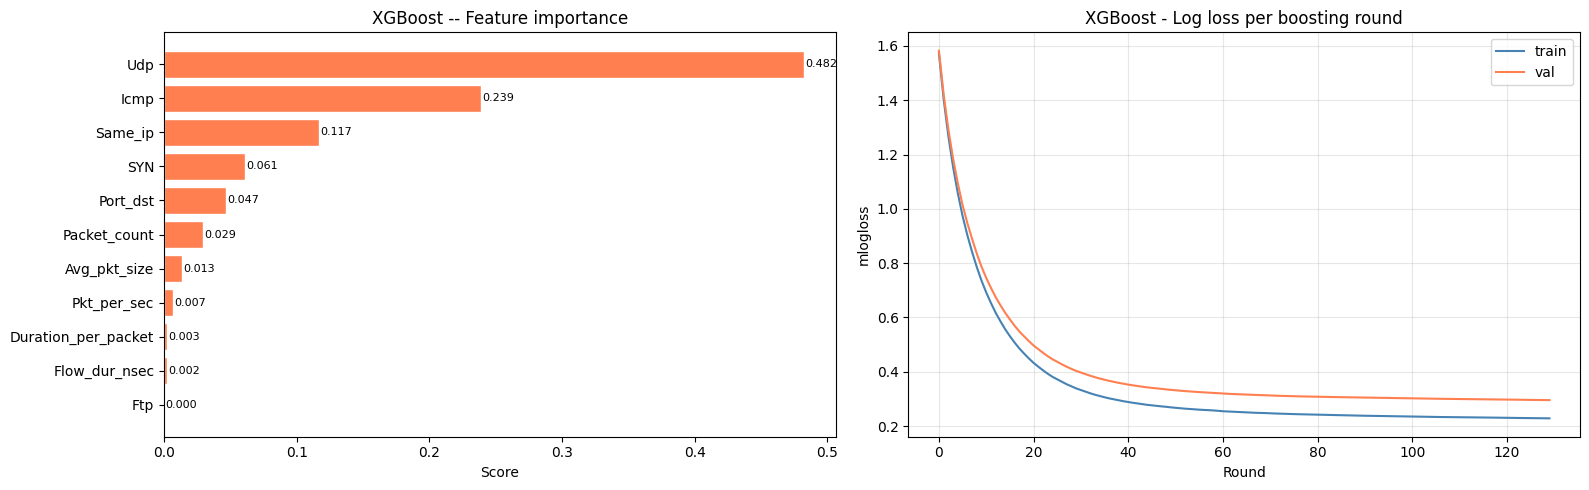

In [35]:
# XGBoost feature importance + learning curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# feature importance
importances = xgb.feature_importances_
indices     = np.argsort(importances)[::-1]
feat_names  = [FINAL_FEATURES[i] for i in indices]

axes[0].barh(feat_names[::-1], importances[indices][::-1],
             color='coral', edgecolor='white')
axes[0].set_title('XGBoost -- Feature importance')
axes[0].set_xlabel('Score')
for i, v in enumerate(importances[indices][::-1]):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# evals result -- retrain with eval set to get learning curve
xgb_eval = XGBClassifier(
    n_estimators=130, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    tree_method='hist',
    random_state=42, n_jobs=-1,
)
eval_set = [(X_train_rf, y_train), (X_test_rf, y_test)]
xgb_eval.fit(X_train_rf, y_train,
             eval_set=eval_set,
             verbose=False)

results   = xgb_eval.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

axes[1].plot(train_loss, label='train', color='steelblue', linewidth=1.5)
axes[1].plot(val_loss,   label='val',   color='coral',     linewidth=1.5)
axes[1].set_title('XGBoost - Log loss per boosting round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('mlogloss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix

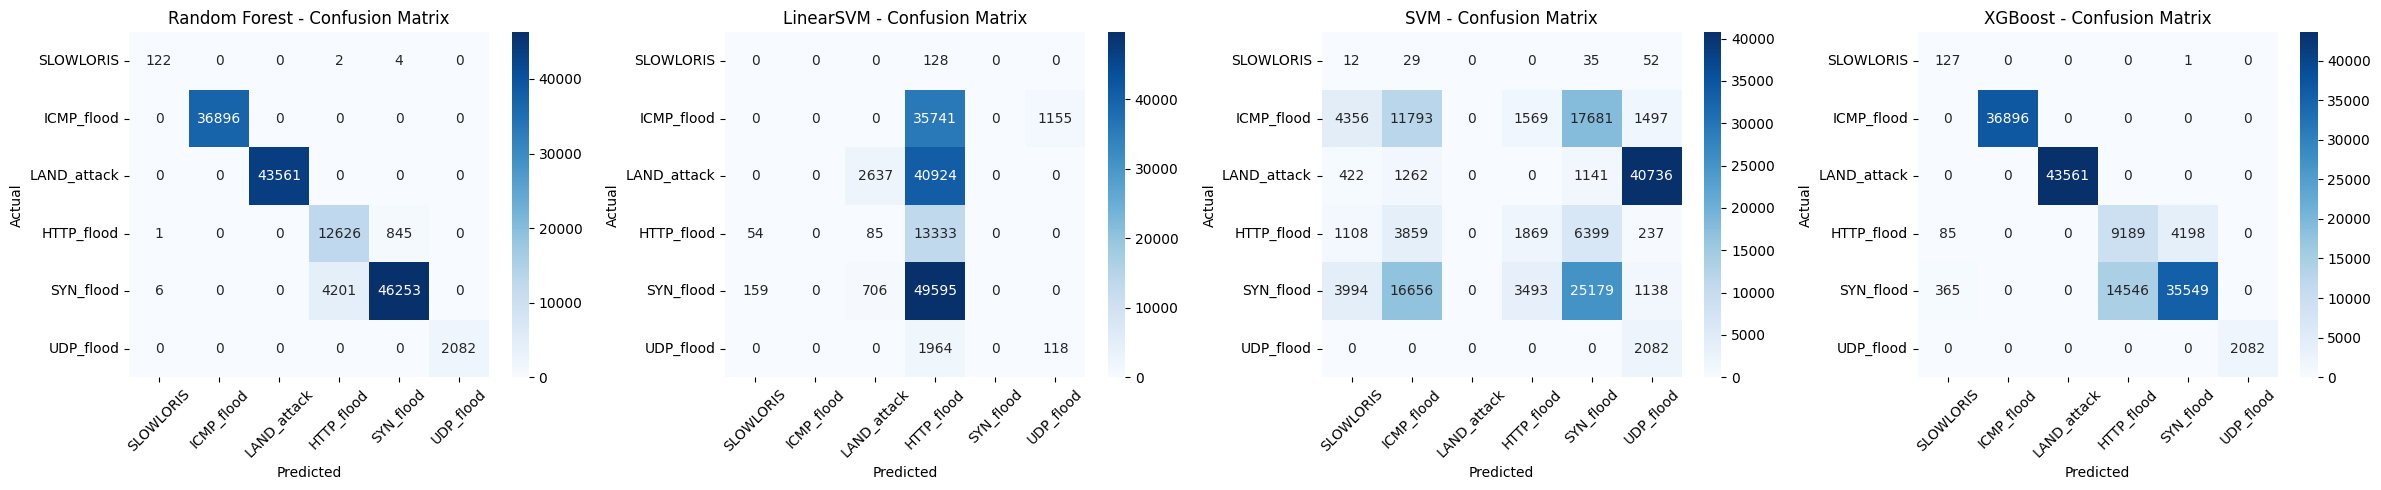

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
labels = list(ATTACK_LABELS.values())

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_linsvm, y_pred_svm, y_pred_xgb],
    ['Random Forest', 'LinearSVM', 'SVM', 'XGBoost'],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax,
    )
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Per-class F1 score comparison between RF, SVM and LinearSVM

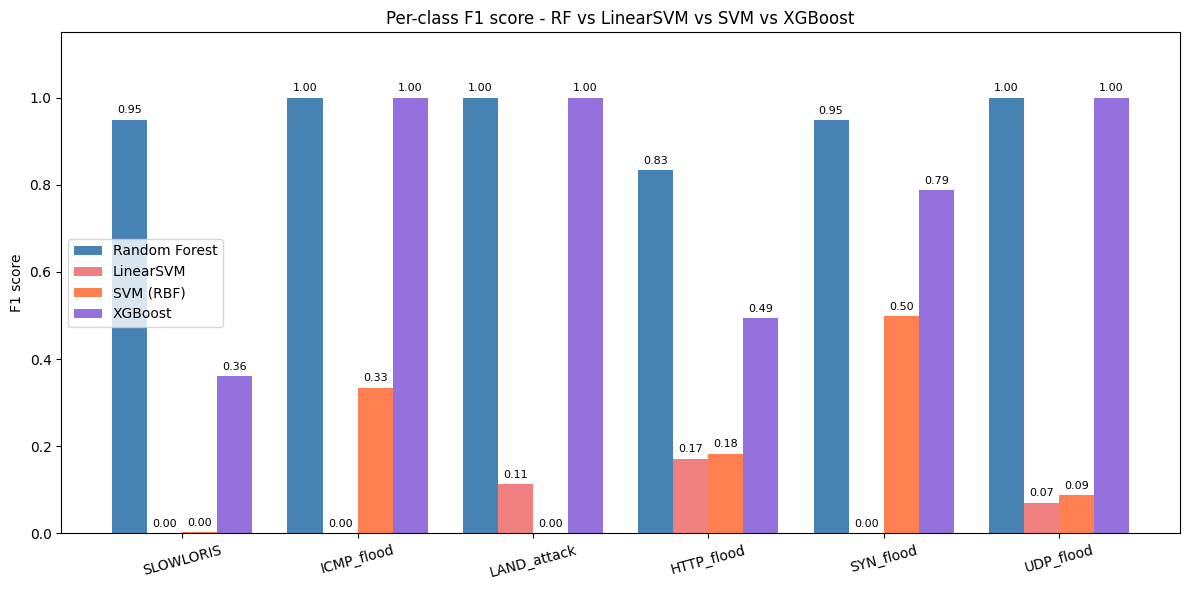

In [38]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

f1_rf  = f1_score(y_test, y_pred_rf,  average=None, labels=list(ATTACK_LABELS.keys()))
f1_linsvm = f1_score(y_test, y_pred_linsvm, average=None, labels=list(ATTACK_LABELS.keys()))
f1_svm = f1_score(y_test, y_pred_svm, average=None, labels=list(ATTACK_LABELS.keys()))
f1_xgb = f1_score(y_test, y_pred_xgb, average=None, labels=list(ATTACK_LABELS.keys()))

x     = np.arange(len(ATTACK_LABELS))
width = 0.20

fig, ax = plt.subplots(figsize=(12, 6))

bars_rf     = ax.bar(x - 1.5*width, f1_rf,     width, label='Random Forest', color='steelblue')
bars_linsvm = ax.bar(x - 0.5*width, f1_linsvm, width, label='LinearSVM',     color='lightcoral')
bars_svm    = ax.bar(x + 0.5*width, f1_svm,    width, label='SVM (RBF)',      color='coral')
bars_xgb    = ax.bar(x + 1.5*width, f1_xgb,    width, label='XGBoost',        color='mediumpurple')

ax.set_xticks(x)
ax.set_xticklabels(list(ATTACK_LABELS.values()), rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 score')
ax.set_title('Per-class F1 score - RF vs LinearSVM vs SVM vs XGBoost')
ax.legend()

# Fixed combining the 4 sets of bars into one list
for bar in list(bars_rf) + list(bars_linsvm) + list(bars_svm) + list(bars_xgb):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=8,
    )

plt.tight_layout()
plt.show()

# Comparison between RF, SVM and LinearSVM results

d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\University\2026-02_Semester-8\Ericsson internship\SDN-IDS\notebooks\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


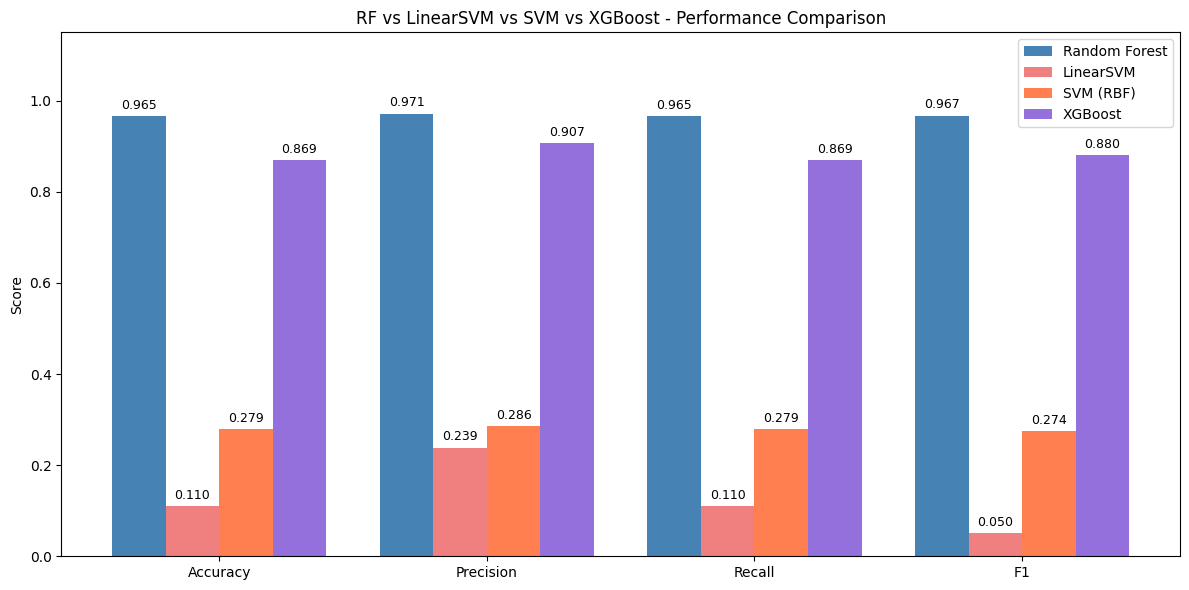

In [41]:
metrics = {
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_linsvm),
                  accuracy_score(y_test, y_pred_svm),
                  accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_rf, average='weighted'),
                  precision_score(y_test, y_pred_linsvm, average='weighted'),
                  precision_score(y_test, y_pred_svm, average='weighted'),
                  precision_score(y_test, y_pred_xgb, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_rf, average='weighted'),
                  recall_score(y_test, y_pred_linsvm, average='weighted'),
                  recall_score(y_test, y_pred_svm, average='weighted'),
                  recall_score(y_test, y_pred_xgb, average='weighted')],
    'F1':        [f1_score(y_test, y_pred_rf, average='weighted'),
                  f1_score(y_test, y_pred_linsvm, average='weighted'),
                  f1_score(y_test, y_pred_svm, average='weighted'),
                  f1_score(y_test, y_pred_xgb, average='weighted')],
}

x     = np.arange(len(metrics))
width = 0.20

fig, ax = plt.subplots(figsize=(12, 6))

bars_rf     = ax.bar(x - 1.5*width, [v[0] for v in metrics.values()], width, label='Random Forest', color='steelblue')
bars_linsvm = ax.bar(x - 0.5*width, [v[1] for v in metrics.values()], width, label='LinearSVM',     color='lightcoral')
bars_svm    = ax.bar(x + 0.5*width, [v[2] for v in metrics.values()], width, label='SVM (RBF)',      color='coral')
bars_xgb    = ax.bar(x + 1.5*width, [v[3] for v in metrics.values()], width, label='XGBoost',        color='mediumpurple')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('RF vs LinearSVM vs SVM vs XGBoost - Performance Comparison')
ax.legend()

# Consolidated labels loop
for bar in list(bars_rf) + list(bars_linsvm) + list(bars_svm) + list(bars_xgb):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Save models

In [42]:
with open('../ryu-controller/RF.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../ryu-controller/LinearSVM.pkl', 'wb') as f:
    pickle.dump(svm_linear, f)

with open('../ryu-controller/SVM_RBF.pkl', 'wb') as f:
    pickle.dump(svm_rbf, f)

with open('../ryu-controller/XGB.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print('Models saved.')

scores = {
    'RF':        accuracy_score(y_test, y_pred_rf),
    'LinearSVM': accuracy_score(y_test, y_pred_linsvm),
    'SVM_RBF':   accuracy_score(y_test, y_pred_svm),
    'XGBoost':   accuracy_score(y_test, y_pred_xgb),
}
best = max(scores, key=scores.get)
for name, score in scores.items():
    print(f'{name}: {score:.4f}')
print(f'\nBest model: {best}')

Models saved.
RF: 0.9655
LinearSVM: 0.1097
SVM_RBF: 0.2792
XGBoost: 0.8691

Best model: RF


### Saving the models as `onnx` files for compatibility with RYU on python 3.8

In [51]:
import pickle
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from onnxmltools import convert_xgboost

n_features   = len(FINAL_FEATURES)
initial_type = [('float_input', FloatTensorType([None, n_features]))]

> Comment the pickle loading block if you want to save the models directly after training. I loaded them to save thema after closing the notbook, and to minimize memory usage while doing that.

In [ ]:
# Run when model is ready and variables are gone
with open('../ryu-controller/RF.pkl', 'rb') as f:
    rf = pickle.load(f)

In [57]:
rf_onnx = convert_sklearn(
    rf, 
    initial_types=initial_type,
    target_opset=11, 
    options={id(rf): {'zipmap': False}}
)
with open('../ryu-controller/RF.onnx', 'wb') as f:
    f.write(rf_onnx.SerializeToString())

print('RF.onnx saved.')

RF.onnx saved.


In [44]:
# Run when model is ready and variables are gone
with open('../ryu-controller/LinearSVM.pkl', 'rb') as f:
    svm_linear = pickle.load(f)

In [45]:
linsvm_onnx = convert_sklearn(svm_linear, initial_types=initial_type)
with open('../ryu-controller/LinearSVM.onnx', 'wb') as f:
    f.write(linsvm_onnx.SerializeToString())

print('LinearSVM.onnx saved.')

LinearSVM.onnx saved.


In [ ]:
# Run when model is ready and variables are gone
with open('../ryu-controller/SVM_RBF.pkl', 'rb') as f:
    svm_rbf = pickle.load(f)

In [46]:
svm_rbf_onnx = convert_sklearn(svm_rbf, initial_types=initial_type)
with open('../ryu-controller/SVM_RBF.onnx', 'wb') as f:
    f.write(svm_rbf_onnx.SerializeToString())

print('SVM_RBF.onnx saved.')

SVM_RBF.onnx saved.


In [49]:
# Run when model is ready and variables are gone
with open('../ryu-controller/XGB.pkl', 'rb') as f:
    xgb = pickle.load(f)

In [55]:
from onnxmltools.convert.common.data_types import FloatTensorType as OnnxFloatTensorType

bstr = xgb.get_booster()
bstr.feature_names = [f'f{i}' for i in range(len(FINAL_FEATURES))]

n_features = len(FINAL_FEATURES)
xgb_initial_type = [('float_input', OnnxFloatTensorType([None, n_features]))]

xgb_onnx = convert_xgboost(
    xgb,
    initial_types=xgb_initial_type,
    target_opset=11
)

with open('../ryu-controller/XGB.onnx', 'wb') as f:
    f.write(xgb_onnx.SerializeToString())

print('XGB.onnx saved')

XGB.onnx saved
